# Bayesian Posterior

# SGLD
+ The update rule is simple as follows:
+ Assuming that the form of the infered function is fixed as $f(x; w)$
$$
w_{t + 1} = w_t - \epsilon_t \frac{d}{dw} \{- \log p(y_D | x_D, w_t) - \log p_0(w) \} + \sqrt{2\epsilon_t} \eta_t,
$$
+ $\epsilon_t$ is postive value, which decays to 0
+ $\eta_t ~ N(0, I_k)$, where $k$ is dimension of the parameters $w$
+ Like other MCMC, SGLD consists of burn-in step and sampling step

In [1]:
%matplotlib inline

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def calc_diff_of_param(param_a: float, param_b: float, x: np.ndarray) -> np.ndarray:
    """ calc diff at x
    """
    return np.array([np.tanh(param_b*x), param_a*x/np.cosh(param_b*x)**2]).T

In [7]:
def forward(param_a: float, param_b: float, x: np.ndarray) -> np.ndarray:
    return param_a * np.tanh(param_b * x)

In [9]:
def sgld_sample(
    param: np.ndarray,
    y: np.ndarray,
    x: np.ndarray,
    pri_beta: float,
    eps_t: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """ calc for the next step of SGLD on function space
    param: tuple of a and b
    """
    param_a, param_b = param
    dw_logp = (y - forward(param_a, param_b, x)) @ calc_diff_of_param(param_a, param_b, x)
    dw_logp0 = -pri_beta * param
    dU_t = dw_logp + dw_logp0
    est_param = param + eps_t * dU_t + np.sqrt(2 * eps_t) * np.random.normal(size=dim_param)

    return est_param, dU_t, dw_logp

# Regular case

In [11]:
ln_seed = 20240515

In [13]:
true_a=1.0
true_b=1.0

In [15]:
data_seed = 20251008
n = 100
np.random.seed(data_seed)
# train_x = np.random.normal(size=n)
train_x = np.random.uniform(low=-10, high=10, size=n)
true_func = true_a * np.tanh(true_b * train_x)
train_y = true_func + 1.0 * np.random.normal(size=n)

In [17]:
# assume the first element is a, the second is b
dim_param = 2

In [19]:
pri_beta = 1.0

In [21]:
eps_0 = 0.001
decay_factor = 0.9
decay_cycle = 1000

In [23]:
burnin = 5000
n_post_samples = 1000
sample_cycle = 100

In [25]:
np.random.seed(ln_seed)
est_param = np.random.normal(size=dim_param)

eps_t = eps_0

history_param = []
history_logp = []
history_param.append(est_param)

In [27]:
n_total_loop = 1

## burn in step

In [29]:
for n_ite in range(burnin):    
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor

    est_param, dU_t, dw_logp = sgld_sample(est_param, train_y, train_x, pri_beta, eps_t)
    history_param.append(est_param)
    history_logp.append(dw_logp)

    n_total_loop += 1
    pass

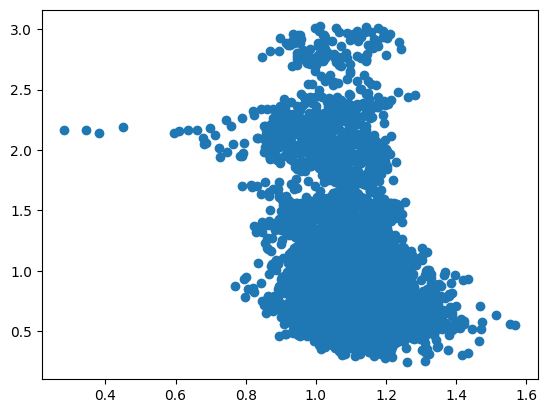

In [31]:
plot_xy = np.array(history_param)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

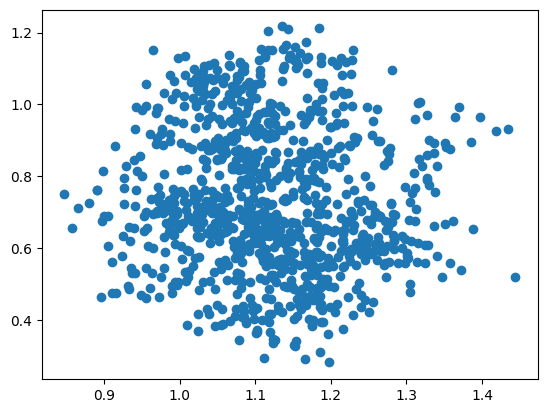

In [33]:
plot_xy = np.array(history_param)[-1000:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

## sampling step

In [45]:
post_params = []

In [47]:
n_post_loop = 1
while len(post_params) < n_post_samples:
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor

    est_param, dU_t, dw_logp = sgld_sample(est_param, train_y, train_x, pri_beta, eps_t)
    
    history_param.append(est_param)
    history_logp.append(dw_logp)

    if n_post_loop % sample_cycle == 0:
        post_params.append(est_param)
    
    n_total_loop += 1
    n_post_loop += 1
    pass

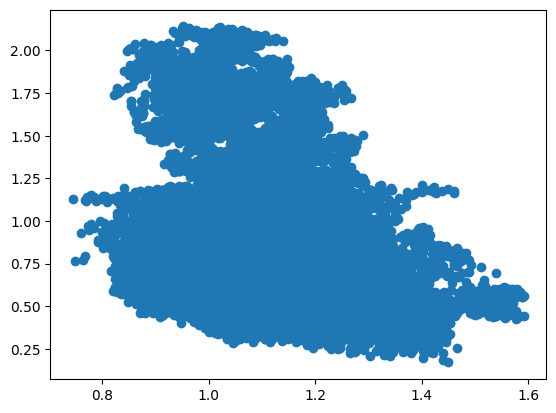

In [48]:
plot_xy = np.array(history_param)[burnin:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

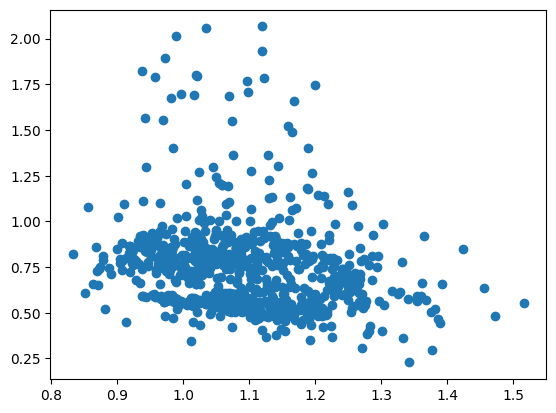

In [51]:
plot_xy = np.array(post_params)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

In [53]:
test_x = np.linspace(-5, 5, num=100)
test_y = forward(true_a, true_b, test_x)

In [55]:
post_funcs = np.array([forward(post_param[0], post_param[1], test_x) for post_param in post_params])

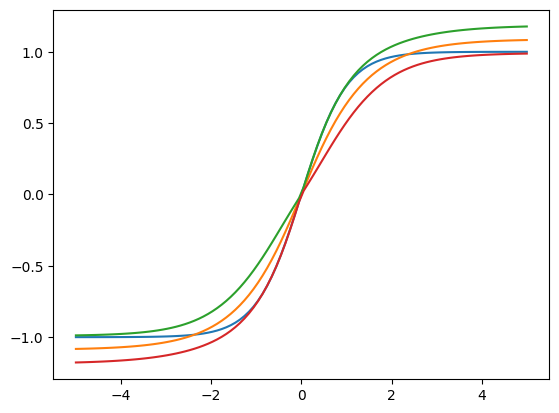

In [57]:
plt.plot(test_x, test_y)
plt.plot(test_x, post_funcs.mean(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) + post_funcs.std(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) - post_funcs.std(axis=0))
plt.show()

# Singular case

In [61]:
ln_seed = 20240515

In [63]:
true_a=0.0
true_b=0.0

In [65]:
data_seed = 20251008
n = 100
np.random.seed(data_seed)
# train_x = np.random.normal(size=n)
train_x = np.random.uniform(low=-10, high=10, size=n)
true_func = true_a * np.tanh(true_b * train_x)
train_y = true_func + 1.0 * np.random.normal(size=n)

In [67]:
# assume the first element is a, the second is b
dim_param = 2

In [69]:
pri_beta = 1.0

In [71]:
eps_0 = 0.001
decay_factor = 0.9
decay_cycle = 1000

In [73]:
burnin = 5000
n_post_samples = 1000
sample_cycle = 100

In [75]:
np.random.seed(ln_seed)
est_param = np.random.normal(size=dim_param)

eps_t = eps_0

history_param = []
history_logp = []
history_param.append(est_param)

In [77]:
n_total_loop = 1

## burn in step

In [80]:
for n_ite in range(burnin):    
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor

    est_param, dU_t, dw_logp = sgld_sample(est_param, train_y, train_x, pri_beta, eps_t)
    history_param.append(est_param)
    history_logp.append(dw_logp)

    n_total_loop += 1
    pass

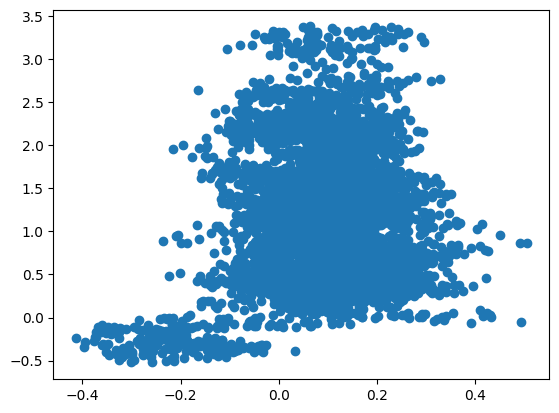

In [82]:
plot_xy = np.array(history_param)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

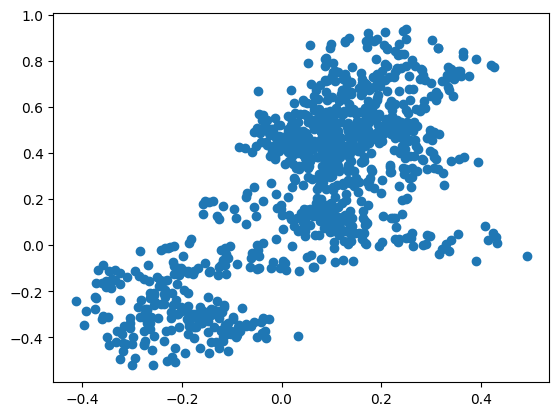

In [84]:
plot_xy = np.array(history_param)[-1000:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

## sampling step

In [87]:
post_params = []

In [89]:
n_post_loop = 1
while len(post_params) < n_post_samples:
    if n_total_loop % decay_cycle == 0:
        eps_t *= decay_factor

    est_param, dU_t, dw_logp = sgld_sample(est_param, train_y, train_x, pri_beta, eps_t)
    
    history_param.append(est_param)
    history_logp.append(dw_logp)

    if n_post_loop % sample_cycle == 0:
        post_params.append(est_param)
    
    n_total_loop += 1
    n_post_loop += 1
    pass

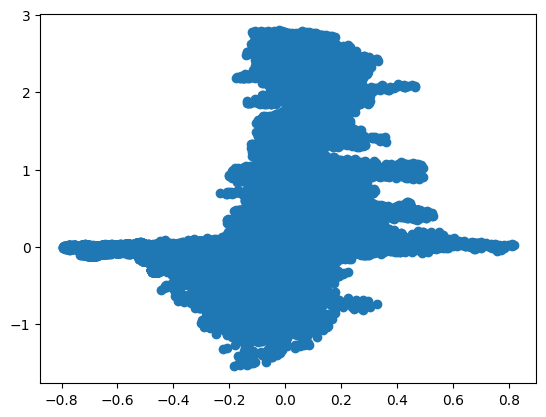

In [90]:
plot_xy = np.array(history_param)[burnin:]
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

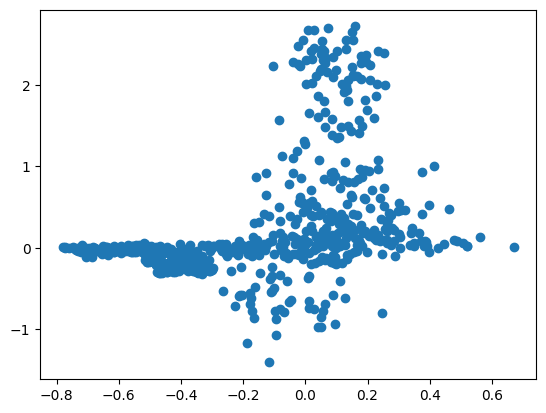

In [95]:
plot_xy = np.array(post_params)
plt.scatter(plot_xy[:,0], plot_xy[:,1])
plt.show()

In [97]:
test_x = np.linspace(-5, 5, num=100)
test_y = forward(true_a, true_b, test_x)

In [99]:
post_funcs = np.array([forward(post_param[0], post_param[1], test_x) for post_param in post_params])

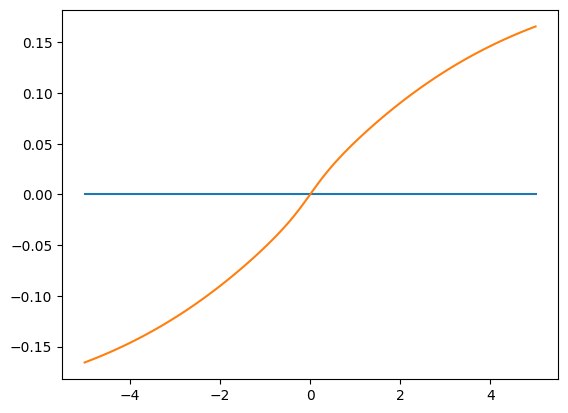

In [103]:
plt.plot(test_x, test_y)
plt.plot(test_x, post_funcs.mean(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) + post_funcs.std(axis=0))
plt.plot(test_x, post_funcs.mean(axis=0) - post_funcs.std(axis=0))
plt.show()